
## Т14

Даны две независимые выборки из нормальных распределений:

- $\xi_i \sim N(a_1, \sigma_1^2)$, где $\sigma_1^2 = 2$;
- $\eta_i \sim N(a_2, \sigma_2^2)$, где $\sigma_2^2 = 1$.

Нужно проверить гипотезу
$$H_0: a_1=a_2$$
против альтернативы
$$H_1: a_1>a_2.$$

Так как дисперсии известны, используем односторонний Z-критерий:
$$Z=\frac{\overline X-\overline Y}{\sqrt{\sigma_1^2/n+\sigma_2^2/m}}.$$

Критическая область:
$$Z>z_{1-\alpha}.$$


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

sample_x = np.array([-1.11, -6.10, 2.42])
sample_y = np.array([-2.29, -2.91])

sigma_x2 = 2
sigma_y2 = 1
alpha = 0.05

n = len(sample_x)
m = len(sample_y)
x_bar = sample_x.mean()
y_bar = sample_y.mean()
se = np.sqrt(sigma_x2 / n + sigma_y2 / m)
z_obs = (x_bar - y_bar) / se
z_crit = norm.ppf(1 - alpha)

print(f'Среднее по первой выборке: {x_bar:.4f}')
print(f'Среднее по второй выборке: {y_bar:.4f}')
print(f'Стандартная ошибка: {se:.4f}')
print(f'Наблюдаемое значение статистики: {z_obs:.4f}')
print(f'Критическое значение: {z_crit:.4f}')
print('Вывод: H0 отвергается' if z_obs > z_crit else 'Вывод: оснований отвергать H0 нет')


Среднее по первой выборке: -1.5967
Среднее по второй выборке: -2.6000
Стандартная ошибка: 1.0801
Наблюдаемое значение статистики: 0.9289
Критическое значение: 1.6449
Вывод: оснований отвергать H0 нет



Получили $Z_{obs}<z_{1-\alpha}$, поэтому статистически значимых оснований утверждать, что $a_1>a_2$, нет.

Функция мощности зависит от сдвига
$$\Delta=a_1-a_2$$
и имеет вид
$$W(\Delta)=1-\Phi\left(z_{1-\alpha}-\frac{\Delta}{\sqrt{\sigma_1^2/n+\sigma_2^2/m}}\right).$$


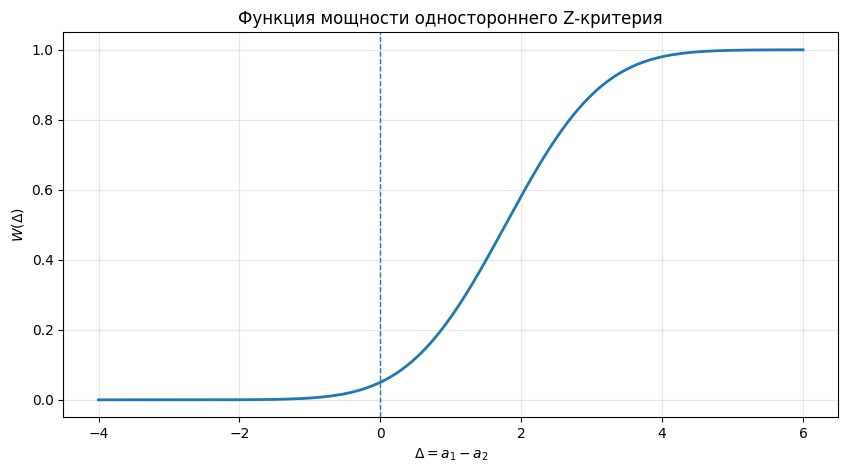

In [2]:

def power_z(delta, sigma1_sq, sigma2_sq, n, m, alpha=0.05):
    se = np.sqrt(sigma1_sq / n + sigma2_sq / m)
    z_alpha = norm.ppf(1 - alpha)
    return 1 - norm.cdf(z_alpha - delta / se)

delta_grid = np.linspace(-4, 6, 800)
power_values = power_z(delta_grid, sigma_x2, sigma_y2, n, m, alpha)

plt.figure(figsize=(10, 5))
plt.plot(delta_grid, power_values, linewidth=2)
plt.axvline(0, linestyle='--', linewidth=1)
plt.xlabel(r'$\Delta = a_1 - a_2$')
plt.ylabel(r'$W(\Delta)$')
plt.title('Функция мощности одностороннего Z-критерия')
plt.grid(True, alpha=0.3)
plt.show()
